In [1]:
print("hello")

hello


In [2]:
#importing Libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import joblib

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\Dhanush V
[nltk_data]     Shetty/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Dhanush V
[nltk_data]     Shetty/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
df = pd.read_csv("C:/InternProject/DataSet/fake_job_postings.csv")

In [4]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

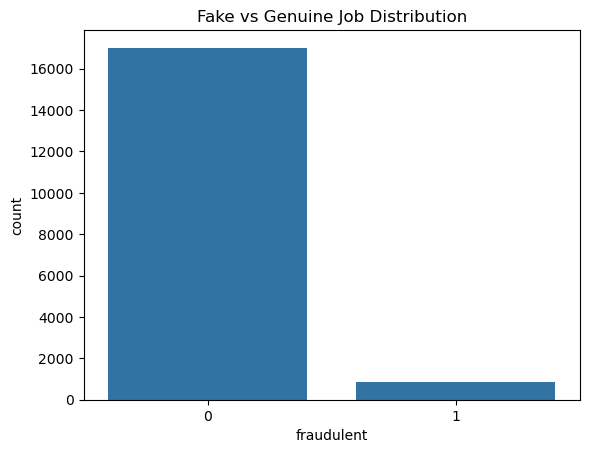

In [5]:
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nTarget Variable Distribution:\n")
print(df['fraudulent'].value_counts())

sns.countplot(x='fraudulent', data=df)
plt.title("Fake vs Genuine Job Distribution")
plt.show()


In [7]:
df = df.drop_duplicates()

# Fill missing text columns with empty string
text_columns = [
    'title',
    'description',
    'requirements',
    'company_profile'
]

for col in text_columns:
    df[col] = df[col].fillna("")

# Drop irrelevant columns if present
columns_to_drop = [
    'job_id',
    'department'
]

for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [8]:

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

for col in text_columns:
    df[col] = df[col].apply(preprocess_text)


In [9]:

df['combined_text'] = (
    df['title'] + " " +
    df['description'] + " " +
    df['requirements'] + " " +
    df['company_profile']
)


In [10]:

X = df['combined_text']
y = df['fraudulent']

# TF-IDF Vectorization

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (14077, 5000)
Testing Shape: (3520, 5000)



Training Logistic Regression...
Accuracy: 0.9698863636363636
Precision: 0.6497695852534562
Recall: 0.8245614035087719
F1 Score: 0.7268041237113402


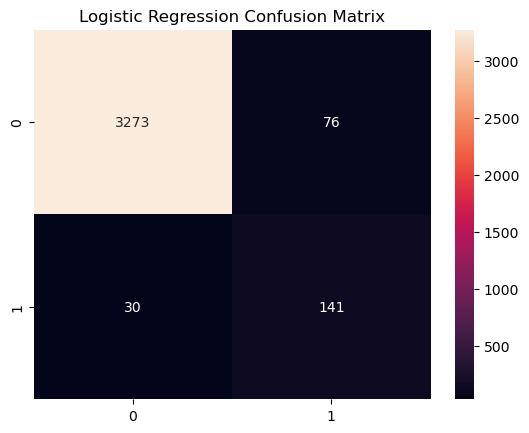


Training Random Forest...
Accuracy: 0.9789772727272728
Precision: 0.970873786407767
Recall: 0.5847953216374269
F1 Score: 0.7299270072992701


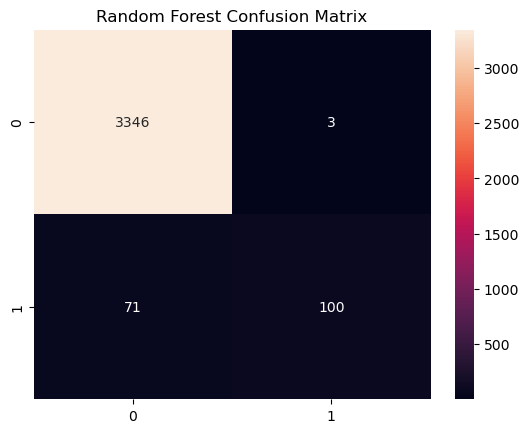


Training SVM...
Accuracy: 0.9821022727272727
Precision: 0.95
Recall: 0.6666666666666666
F1 Score: 0.7835051546391752


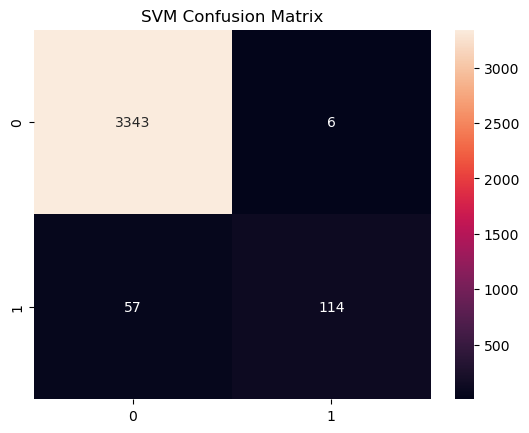


Training Naive Bayes...
Accuracy: 0.9088068181818182
Precision: 0.33766233766233766
Recall: 0.9122807017543859
F1 Score: 0.4928909952606635


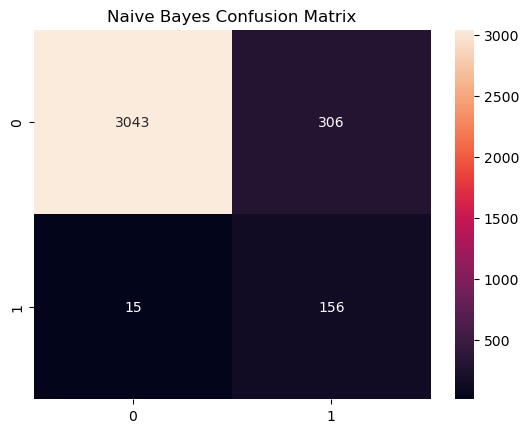


Training KNN...
Accuracy: 0.759090909090909
Precision: 0.1645193260654113
Recall: 0.9707602339181286
F1 Score: 0.28135593220338984


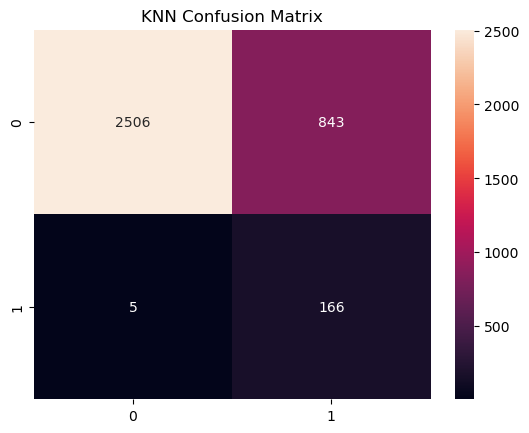

In [29]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced"
    ),

    "SVM": SVC(
        class_weight="balanced"
    ),

    "Naive Bayes": MultinomialNB(),

    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name + " Confusion Matrix")
    plt.show()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [30]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

print("\nModel Comparison:")
print(results_df.sort_values(by='F1 Score', ascending=False))


Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
2                  SVM  0.982102   0.950000  0.666667  0.783505
1        Random Forest  0.978977   0.970874  0.584795  0.729927
0  Logistic Regression  0.969886   0.649770  0.824561  0.726804
3          Naive Bayes  0.908807   0.337662  0.912281  0.492891
4                  KNN  0.759091   0.164519  0.970760  0.281356


In [31]:

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [32]:
y_pred_best = best_model.predict(X_test)

print("\nFinal Model Performance:")

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


Final Model Performance:
Accuracy: 0.9809659090909091
Precision: 0.9814814814814815
Recall: 0.6198830409356725
F1 Score: 0.7598566308243727

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3349
           1       0.98      0.62      0.76       171

    accuracy                           0.98      3520
   macro avg       0.98      0.81      0.87      3520
weighted avg       0.98      0.98      0.98      3520



In [33]:
joblib.dump(best_model, "fake_job_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


In [34]:
def predict_job(title, location, description):

    model = joblib.load("fake_job_model.pkl")
    vectorizer = joblib.load("tfidf_vectorizer.pkl")

    text = title + " " + location + " " + description

    text = preprocess_text(text)

    text_vector = vectorizer.transform([text])

    prediction = model.predict(text_vector)[0]

    if prediction == 1:
        return "Fake Job"
    else:
        return "Genuine Job"

In [35]:
print(
    predict_job(
        title="Software Engineer",
        location="Bangalore",
        description="Looking for Python developer with SQL experience"
    )
)

Genuine Job


In [20]:
predict_job(
    title="Data Entry Clerk - Work From Home",
    location="Remote",
    description="""
We are urgently hiring data entry operators to work from home.
No experience required. Earn up to $3000 per week.
You must pay a small registration fee of $50 to get started.
Limited positions available. Apply immediately.
"""
)

'Fake Job'

In [36]:
predict_job(
    title="Online Part Time Job",
    location="Work From Home",
    description="""
Make money easily from home with our simple online job.
No skills required. Earn daily income.
Contact us on WhatsApp to start immediately.
Processing fee required before joining.
"""
)

'Fake Job'

In [37]:
predict_job(
    title="Software Engineer",
    location="Bangalore",
    description="""
We are looking for a Software Engineer with experience in Python,
SQL, and REST APIs. The candidate will work with the development
team to build scalable backend systems.
"""
)

'Genuine Job'

In [38]:
predict_job(
    title="Earn Money From Home",
    location="Remote",
    description="""
No experience required.
Earn $5000 per week.
Registration fee required.
Contact on WhatsApp immediately.
"""
)

'Fake Job'

In [39]:
predict_job(
    title="Earn Money From Home",
    location="Remote",
    description="""
No experience required.
Earn $5000 per week.
Registration fee required.
Contact on WhatsApp immediately.
"""
)

'Fake Job'

In [40]:
predict_job(
    title="Earn Money From Home",
    location="Remote",
    description="""
No experience required.
Earn $5000 per week.
Registration fee required.
Contact on WhatsApp immediately.
"""
)

'Fake Job'